In [2]:
import edes 
from edes.utils.plotting import plot, plot_ax, big_plt_font, plot_ax_errbar, plot_errbar
import numpy as np 
from tqdm import tqdm, trange 
import matplotlib.pyplot as plt 
import time
from edes.utils.file_handling import load_h5_data, load_latest_data, load_latest_filename
big_plt_font()

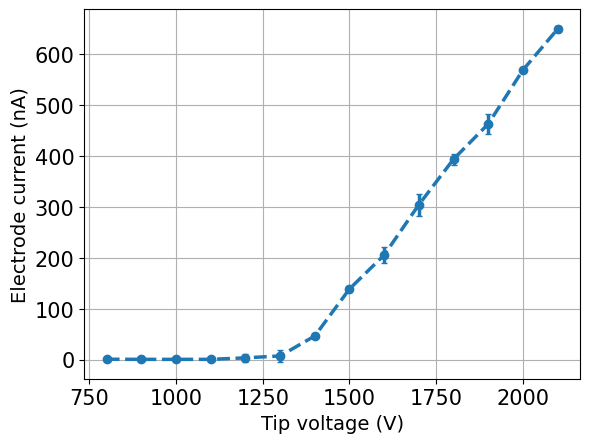

In [6]:
file = load_latest_data() 
plot_errbar(file['all_V'], -np.mean(file['all_I'], axis=1)*1e9, yerr=np.std(file['all_I'], axis=1)*1e9, fmt='.--', xlabel='Tip voltage (V)', ylabel='Electrode current (nA)')
# plt.yscale('log')

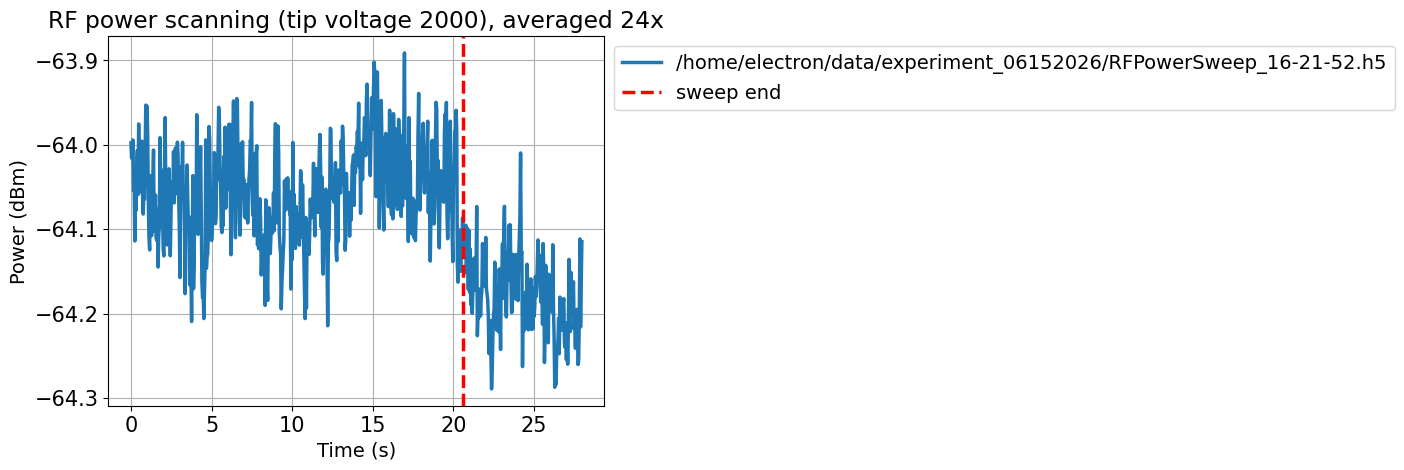

In [28]:
file = load_latest_data()
all_data = file['all_meas'] 
num_points = len(all_data[0])
t_axis = np.linspace(0, 30, num_points) 
idx = np.where(t_axis < 30-2)
plot(t_axis[idx], np.mean(all_data, axis=0)[idx], xlabel='Time (s)', 
     ylabel='Power (dBm)', label=file['filename'], title=f"RF power scanning (tip voltage {file['V_on']}), averaged {file['N_avg']}x")
plt.axvline(file['t_end'][-1]-file['t_start'][-1], linestyle='--', color='r', label='sweep end') 
# plt.axvline(file['t_end'][-1], linestyle='--', color='k', label='sweep end')
# plt.axvline(t_RF_on, linestyle='--', color='g', label='RF on') 
# plt.axvline(t_RF_off, linestyle='--', color='purple', label='RF off')
plt.legend(bbox_to_anchor=(1,1))
plt.show()


In [32]:
np.shape(all_data), np.shape(dBm_scan)

((800, 751), (800,))

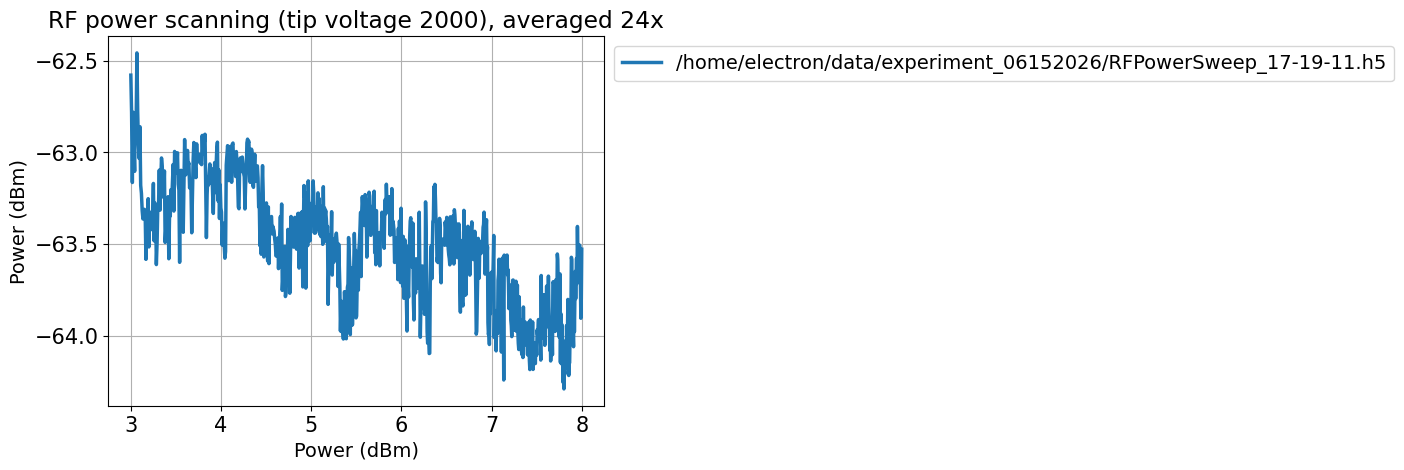

In [35]:
file = load_latest_data()
all_data = file['all_meas'] 
dBm_scan = file['dBm_scan']
# avg_data = np.mean(all_data, axis=0)
num_points = len(all_data[0])
# t_axis = np.linspace(0, 30, num_points) 
# idx = np.where(t_axis < 30-2)
plot(dBm_scan, np.mean(all_data, axis=1), xlabel='Power (dBm)', 
     ylabel='Power (dBm)', label=file['filename'], title=f"RF power scanning (tip voltage {file['V_on']}), averaged {file['N_avg']}x")
# plt.axvline(file['t_end'][-1]-file['t_start'][-1], linestyle='--', color='r', label='sweep end') 
# plt.axvline(file['t_end'][-1], linestyle='--', color='k', label='sweep end')
# plt.axvline(t_RF_on, linestyle='--', color='g', label='RF on') 
# plt.axvline(t_RF_off, linestyle='--', color='purple', label='RF off')
plt.legend(bbox_to_anchor=(1,1))
plt.show()


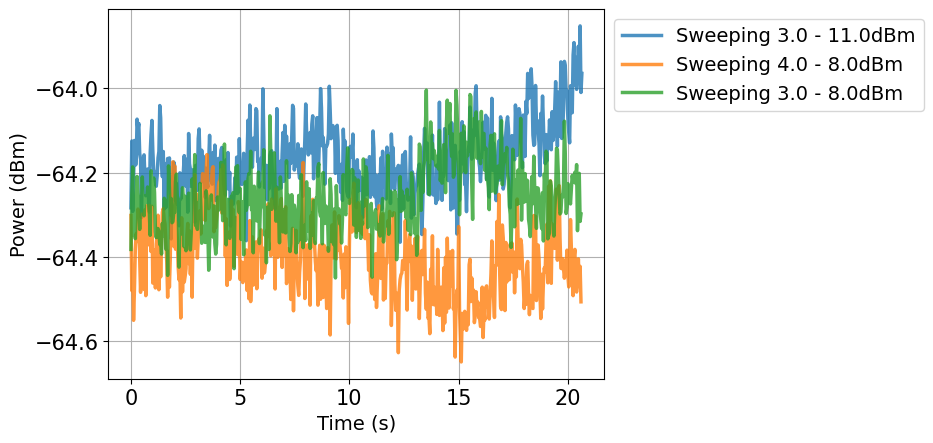

In [27]:
files = ['RFPowerSweep_15-28-20', 'RFPowerSweep_15-45-58', 'RFPowerSweep_15-39-45']
for filename in files:
    file = load_h5_data(filename+'.h5', base=f'{edes.load_saving_dir()}/experiment_06152026')
    all_data = file['all_meas'] 
    num_points = len(all_data[0])
    t_axis = np.linspace(0, 30, num_points) 
    idx = np.where(t_axis < file['t_end'][-1]-file['t_start'][-1])
    plot(t_axis[idx], np.mean(all_data, axis=0)[idx], xlabel='Time (s)', 
        ylabel='Power (dBm)', label=f"Sweeping {file['dBm_scan'][0]:.1f} - {file['dBm_scan'][-1]:.21}dBm", alpha=0.8)#, title=f"RF power scanning (tip voltage {file['V_on']}), averaged {file['N_avg']}x")
    # plt.axvline(file['t_end'][-1]-file['t_start'][-1], linestyle='--', color='r', label='sweep end') 
    # plt.axvline(file['t_end'][-1], linestyle='--', color='k', label='sweep end')
    # plt.axvline(t_RF_on, linestyle='--', color='g', label='RF on') 
    # plt.axvline(t_RF_off, linestyle='--', color='purple', label='RF off')
plt.legend(bbox_to_anchor=(1,1))
plt.show()
